In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
df = pd.read_csv("nba_logreg.csv")

# Quick look
print(df.head())
print(df.info())

              Name  GP   MIN  PTS  FGM  ...  AST  STL  BLK  TOV  TARGET_5Yrs
0   Brandon Ingram  36  27.4  7.4  2.6  ...  1.9  0.4  0.4  1.3          0.0
1  Andrew Harrison  35  26.9  7.2  2.0  ...  3.7  1.1  0.5  1.6          0.0
2   JaKarr Sampson  74  15.3  5.2  2.0  ...  1.0  0.5  0.3  1.0          0.0
3      Malik Sealy  58  11.6  5.7  2.3  ...  0.8  0.6  0.1  1.0          1.0
4      Matt Geiger  48  11.5  4.5  1.6  ...  0.3  0.3  0.4  0.8          1.0

[5 rows x 21 columns]
<class 'pandas.DataFrame'>
RangeIndex: 1340 entries, 0 to 1339
Data columns (total 21 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Name         1340 non-null   str    
 1   GP           1340 non-null   int64  
 2   MIN          1340 non-null   float64
 3   PTS          1340 non-null   float64
 4   FGM          1340 non-null   float64
 5   FGA          1340 non-null   float64
 6   FG%          1340 non-null   float64
 7   3P Made      1340 non-null   float64

In [4]:
from sklearn.preprocessing import LabelEncoder

# Target column (last column assumed)
target_column = df.columns[-1]

# Drop missing values
df = df.dropna()

# Copy dataframe to avoid modifying original
df_encoded = df.copy()

# Encode categorical columns (handles both object + string dtypes)
label_encoders = {}

for col in df_encoded.select_dtypes(include=['object', 'string']).columns:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
    label_encoders[col] = le

In [5]:
X = df.drop(columns=[target_column])
y = df[target_column]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [6]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))
print("\nClassification Report:\n", classification_report(y_test, dt_pred))

Decision Tree Accuracy: 0.6729323308270677

Classification Report:
               precision    recall  f1-score   support

         0.0       0.51      0.66      0.58        90
         1.0       0.79      0.68      0.73       176

    accuracy                           0.67       266
   macro avg       0.65      0.67      0.65       266
weighted avg       0.70      0.67      0.68       266



In [7]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print("\nClassification Report:\n", classification_report(y_test, rf_pred))

Random Forest Accuracy: 0.7593984962406015

Classification Report:
               precision    recall  f1-score   support

         0.0       0.64      0.66      0.65        90
         1.0       0.82      0.81      0.82       176

    accuracy                           0.76       266
   macro avg       0.73      0.73      0.73       266
weighted avg       0.76      0.76      0.76       266



In [8]:
print("Decision Tree Confusion Matrix:\n", confusion_matrix(y_test, dt_pred))
print("\nRandom Forest Confusion Matrix:\n", confusion_matrix(y_test, rf_pred))

Decision Tree Confusion Matrix:
 [[ 59  31]
 [ 56 120]]

Random Forest Confusion Matrix:
 [[ 59  31]
 [ 33 143]]


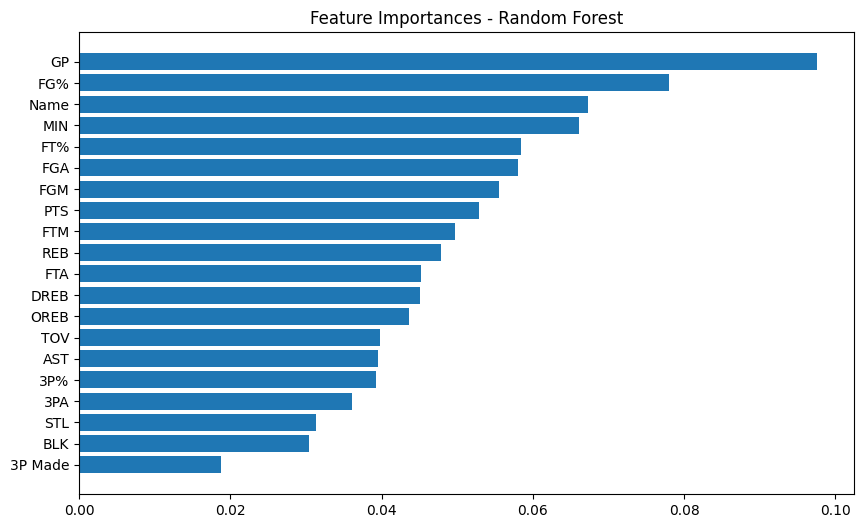

In [9]:
import matplotlib.pyplot as plt

importances = rf_model.feature_importances_
features = X.columns

indices = np.argsort(importances)

plt.figure(figsize=(10,6))
plt.title("Feature Importances - Random Forest")
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), features[indices])
plt.show()